In [36]:
import numpy as np
m1=5;
m2=8;
m3=5;
k1=1000;k2=2000;k3=1000;
c1=1000;c2=2000;c3=1000;

In [37]:

# Mass matrix
M = np.array([
    [m1, 0,  0 ],
    [0,  m2, 0 ],
    [0,  0,  m3]
])

# Stiffness matrix
K = np.array([
    [k1+k2, -k2,    0   ],
    [-k2,   k2+k3,  -k3 ],
    [0,     -k3,    k3  ]
])

# Damping matrix
C = np.array([
    [c1+c2, -c2,    0   ],
    [-c2,   c2+c3,  -c3 ],
    [0,     -c3,    c3  ]
])
print("Mass Matrix M:\n", M)
print("Stiffness Matrix K:\n", K)
print("Damping Matrix C:\n", C)


Mass Matrix M:
 [[5 0 0]
 [0 8 0]
 [0 0 5]]
Stiffness Matrix K:
 [[ 3000 -2000     0]
 [-2000  3000 -1000]
 [    0 -1000  1000]]
Damping Matrix C:
 [[ 3000 -2000     0]
 [-2000  3000 -1000]
 [    0 -1000  1000]]


In [38]:
import numpy as np
# Calculate natural frequencies and mode shapes
Di, Vi = np.linalg.eig(np.linalg.inv(M).dot(K))
print("Mode shape vectors Vi =\n", (Vi))

print("SQUARE OF NATURAL FREQUENCY Di=\n", np.diag(Di))

Mode shape vectors Vi =
 [[-0.84979084 -0.50442954  0.4074314 ]
 [ 0.50289408 -0.38058208  0.57032475]
 [-0.15796538  0.77505362  0.71325265]]
SQUARE OF NATURAL FREQUENCY Di=
 [[836.71428729   0.           0.        ]
 [  0.         298.20793632   0.        ]
 [  0.           0.          40.07777639]]


In [39]:
f = np.sqrt(Di) / (2 * np.pi)
for i in range(len(f)):
    print(f"f{i+1} = {f[i]:.4f} Hz")

f1 = 4.6037 Hz
f2 = 2.7484 Hz
f3 = 1.0076 Hz


In [40]:
import numpy as np
from math import pi
fs=20*max(f)
print(f"Sampling frequency fs = {fs:.4f} Hz")
tmax=1;
dt= 1/fs;
t = np.arange(0, tmax, dt)
omega = 2 * pi *20

Sampling frequency fs = 92.0744 Hz


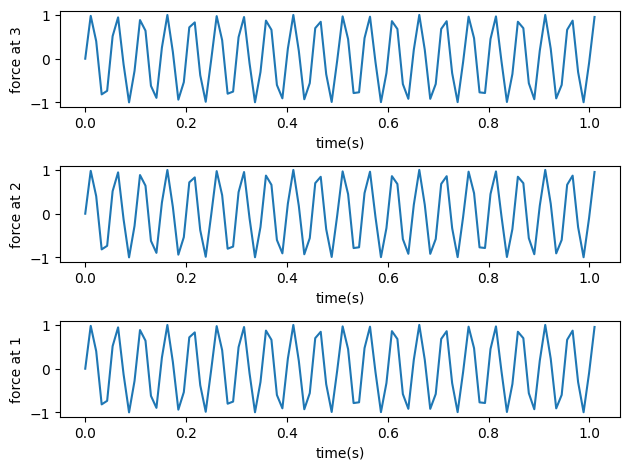

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Create time array
time = np.arange(0, tmax + dt, dt)

#force matrix
force = np.zeros((3, len(time)))

# Force vector loop
i = 0
for t_val in time:
    force[:, i] = np.sin(omega * t_val) * np.ones(3)
    i += 1

# Plotting
plt.figure(1)

plt.subplot(3, 1, 1)
plt.plot(time, force[2, :])
plt.xlabel('time(s)')
plt.ylabel('force at 3')

plt.subplot(3, 1, 2)
plt.plot(time, force[1, :])
plt.xlabel('time(s)')
plt.ylabel('force at 2')

plt.subplot(3, 1, 3)
plt.plot(time, force[0, :])
plt.xlabel('time(s)')
plt.ylabel('force at 1')

plt.tight_layout()
plt.show()

In [42]:
import numpy as np

def Newmark_Beta(M, C, K, f, fs):
    """
    Newmark-Beta time integration method
    
    Input:
        M: mass matrix (n*n)
        C: damping matrix (n*n)
        K: stiffness matrix (n*n)
        f: external force matrix (n, N)
        fs: sampling frequency
        
    where n is the number of degrees of freedom, N is the length of data points of dynamic force
    
    Output:
        x: Displacement (n*N)
        v: Velocity (n*N)
        a: Acceleration (n*N)
    """
    
    n, N = f.shape
    dt = 1/fs  # Sampling rate
    beta = 1/4  # Newmark parameters
    gamma = 1/2  # Newmark parameters
    
    # Initialize arrays
    x = np.zeros((n, N))
    v = np.zeros((n, N))
    a = np.zeros((n, N))
    
    # Initial conditions
    x[:, 0] = np.zeros(n)  # initial displacement
    v[:, 0] = np.zeros(n)  # initial velocity
    a[:, 0] = np.linalg.solve(M, f[:, 0] - C @ v[:, 0] - K @ x[:, 0])  # initial acceleration
    
    # Newmark constants
    a1 = 1/(beta*dt**2)*M + gamma/(beta*dt)*C
    a2 = 1/(beta*dt)*M + (gamma/beta - 1)*C
    a3 = (1/(2*beta) - 1)*M + dt*(gamma/(2*beta) - 1)*C
    K_hat = K + a1
    
    # Time integration loop
    for i in range(N-1):
        F_hat = f[:, i+1] + a1 @ x[:, i] + a2 @ v[:, i] + a3 @ a[:, i]
        x[:, i+1] = np.linalg.solve(K_hat, F_hat)
        v[:, i+1] = gamma/(beta*dt)*(x[:, i+1] - x[:, i]) + (1 - gamma/beta)*v[:, i] + dt*(1 - gamma/(2*beta))*a[:, i]
        a[:, i+1] = 1/(beta*dt**2)*(x[:, i+1] - x[:, i]) - 1/(beta*dt)*v[:, i] - (1/(2*beta) - 1)*a[:, i]
    
    return x, v, a

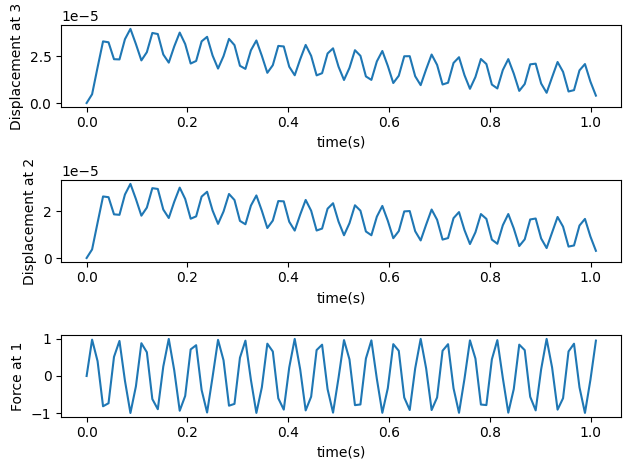

In [43]:
# Solution to equation of motion
x, v, a = Newmark_Beta(M, C, K, force, fs)

# Plot the displacement responses
plt.figure(2)

plt.subplot(3, 1, 1)
plt.plot(time, x[2, :])
plt.xlabel('time(s)')
plt.ylabel('Displacement at 3')

plt.subplot(3, 1, 2)
plt.plot(time, x[1, :])
plt.xlabel('time(s)')
plt.ylabel('Displacement at 2')

plt.subplot(3, 1, 3)
plt.plot(time, force[0, :])
plt.xlabel('time(s)')
plt.ylabel('Force at 1')

plt.tight_layout()
plt.show()